# Análise da Produção e Faturamento de Mel no Brasil

## 1. Introdução

**Membros da Equipe**: Gabriel de Jesus.

O mel, um produto natural de grande valor nutritivo e econômico, desempenha um papel significativo na economia agrícola brasileira. A apicultura, atividade responsável pela sua produção, contribui para a renda de milhares de famílias e é vital para a polinização de diversas culturas agrícolas.

Este projeto tem como objetivo principal analisar os fatores que afetam a produção e o faturamento anual de mel no Brasil. Para isso, exploraremos uma base de dados abrangente, combinando informações sobre a produção e valor do mel com dados climáticos para identificar padrões e tendências.

É importante notar que, para garantir a consistência e a possibilidade de cruzamento das informações, nossa análise se concentrará nos dados do período de 2000 a 2023, que é o intervalo de tempo em que os datasets de produção de mel e de observações climáticas se sobrepõem.

Para mais detalhes sobre as fontes de dados utilizadas e suas especificidades, por favor, consulte o arquivo README.md na raiz deste repositório.



## 2. Preparação e Limpeza dos Dados

#### Bibliotecas utilizadas

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Funções recorrentes

In [112]:
def show_head_tail(df):
    display(df.head(5))
    display(df.tail(5))

In [113]:
def show_max(df, column):
    print("Máximo valor em", column)
    display(df[df[column] == df[column].max()])
    
def show_min(df, column):
    print("Mínimo valor em", column)
    display(df[df[column] == df[column].min()])

In [114]:
def listar_valores_unicos(df, coluna):
    print(f"\nValores únicos na coluna '{coluna}':")
    print(df[coluna].unique())
    print(df[coluna].value_counts())    

### Brasil

#### Em qual ano o Brasil mais faturou com mel?

##### Extração

In [115]:
faturamento_br = pd.read_csv('data/faturamento mel/Faturamento R$ - Mel de Abelha - Brasil - 2000 2023.csv')
faturamento_br

,Sigla,Código,Brasil,2000,2001,2002,2003,2004,2005,2006,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,BR,0,Brasil,191235.44833,179290.160265,205953.340512,269407.150088,267114.750166,243996.10355,253066.578497,...,232378.888835,246313.199961,299400.116727,314682.624086,294926.532107,278263.994179,334416.942334,397418.252929,422375.012785,371282.235818


O dataset esta com os dados ordenados horizontalmente o que dificulta a utilização das ferramentas, vamos tratar esses dados, ordenando eles verticalmente.

In [116]:
melted_faturamento_br = pd.melt(faturamento_br.drop(columns=['Sigla', 'Código']), id_vars=['Brasil'], var_name='Ano', value_name='Faturamento (R$)')
show_head_tail(melted_faturamento_br)

,Brasil,Ano,Faturamento (R$)
0,Brasil,2000,191235.448330
1,Brasil,2001,179290.160265
2,Brasil,2002,205953.340512
3,Brasil,2003,269407.150088
4,Brasil,2004,267114.750166


,Brasil,Ano,Faturamento (R$)
19,Brasil,2019,278263.994179
20,Brasil,2020,334416.942334
21,Brasil,2021,397418.252929
22,Brasil,2022,422375.012785
23,Brasil,2023,371282.235818


In [117]:
melted_faturamento_br.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brasil            24 non-null     object 
 1   Ano               24 non-null     object 
 2   Faturamento (R$)  24 non-null     float64
dtypes: float64(1), object(2)
memory usage: 708.0+ bytes


##### Resultado Bruto

In [118]:
show_max(melted_faturamento_br, 'Faturamento (R$)')
show_min(melted_faturamento_br, 'Faturamento (R$)')

Máximo valor em Faturamento (R$)


,Brasil,Ano,Faturamento (R$)
22,Brasil,2022,422375.012785


Mínimo valor em Faturamento (R$)


,Brasil,Ano,Faturamento (R$)
1,Brasil,2001,179290.160265


Olhando para os dados brutos, 2022 parece ter sido o ano em que o Brasil como um todo mais faturou com a venda de mel. No entanto, para uma análise precisa, é crucial levar em consideração o Índice Nacional de Preços ao Consumidor Amplo (IPCA).

O IPCA é o principal indicador de inflação do país. Ele mede a variação de preços de um conjunto de produtos e serviços, permitindo-nos ajustar os valores monetários ao longo do tempo para o poder de compra real da moeda. Ignorar a inflação faria com que o faturamento de R$1,00 em 2000 fosse considerado igual ao de R$1,00 em 2022, o que é uma comparação incorreta.

Portanto, ao deflacionar o faturamento bruto pelo IPCA, podemos determinar se o faturamento de 2022 realmente representou um aumento no poder de compra dos produtores de mel, ou se essa alta foi apenas um reflexo da inflação. Essa análise revelará o verdadeiro desempenho econômico do setor apícola brasileiro.

##### Reajuste IPCA

In [119]:
df_ipca = pd.read_csv('data/IPCA geral índice (dez. 2023 = 100).csv')
df_ipca

,Data,IPCA - geral - índice (dez. 2023 = 100),Unnamed: 2
0,2000,24.854612,NaN
1,2001,26.761815,NaN
2,2002,30.115144,NaN
3,2003,32.916007,NaN
4,2004,35.417457,NaN
5,2005,37.432437,NaN
6,2006,38.608383,NaN
7,2007,40.329413,NaN
8,2008,42.709947,NaN
9,2009,44.551450,NaN


In [120]:
#removendo coluna desnecessária
df_ipca.drop(columns=['Unnamed: 2'], inplace=True)
#renomeando colunas para facilitar o manuseio
df_ipca.rename(columns={'IPCA - geral - índice (dez. 2023 = 100)': 'IPCA', 'Data':'Ano'}, inplace=True)
display(df_ipca)

,Ano,IPCA
0,2000,24.854612
1,2001,26.761815
2,2002,30.115144
3,2003,32.916007
4,2004,35.417457
5,2005,37.432437
6,2006,38.608383
7,2007,40.329413
8,2008,42.709947
9,2009,44.551450


In [121]:
#Confirmando o tipo de dados e se há valores nulos
df_ipca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ano     24 non-null     int64  
 1   IPCA    24 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 516.0 bytes


In [122]:
# Definir o ano base para o ajuste
ano_base = 2023

# Obter o IPCA do ano base
ipca_base = df_ipca[df_ipca['Ano'] == ano_base]['IPCA'].iloc[0]

# Calcular o fator de correção para cada ano
df_ipca['fator_ajuste'] = ipca_base / df_ipca['IPCA']
df_ipca

,Ano,IPCA,fator_ajuste
0,2000,24.854612,4.023398
1,2001,26.761815,3.736667
2,2002,30.115144,3.320588
3,2003,32.916007,3.038036
4,2004,35.417457,2.823466
5,2005,37.432437,2.671480
6,2006,38.608383,2.590111
7,2007,40.329413,2.479580
8,2008,42.709947,2.341375
9,2009,44.551450,2.244596


In [123]:
melted_faturamento_br['Ano'] = melted_faturamento_br['Ano'].astype(int)

In [124]:
melted_faturamento_br = melted_faturamento_br.merge(df_ipca[['Ano', 'fator_ajuste']], on='Ano', how='left')
melted_faturamento_br['Faturamento Ajustado (R$)'] = melted_faturamento_br['Faturamento (R$)'] * melted_faturamento_br['fator_ajuste']
melted_faturamento_br

,Brasil,Ano,Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
0,Brasil,2000,191235.448330,4.023398,769416.339531
1,Brasil,2001,179290.160265,3.736667,669947.680919
2,Brasil,2002,205953.340512,3.320588,683886.292978
3,Brasil,2003,269407.150088,3.038036,818468.514089
4,Brasil,2004,267114.750166,2.823466,754189.520224
5,Brasil,2005,243996.103550,2.671480,651830.672987
6,Brasil,2006,253066.578497,2.590111,655470.550902
7,Brasil,2007,231621.329561,2.479580,574323.589253
8,Brasil,2008,231959.899120,2.341375,543105.102187
9,Brasil,2009,240039.512975,2.244596,538791.695376


##### Resultado com reajuste

In [125]:
show_max(melted_faturamento_br, 'Faturamento Ajustado (R$)')
show_min(melted_faturamento_br, 'Faturamento Ajustado (R$)')

Máximo valor em Faturamento Ajustado (R$)


,Brasil,Ano,Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
3,Brasil,2003,269407.150088,3.038036,818468.514089


Mínimo valor em Faturamento Ajustado (R$)


,Brasil,Ano,Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
19,Brasil,2019,278263.994179,1.273111,354261.014774


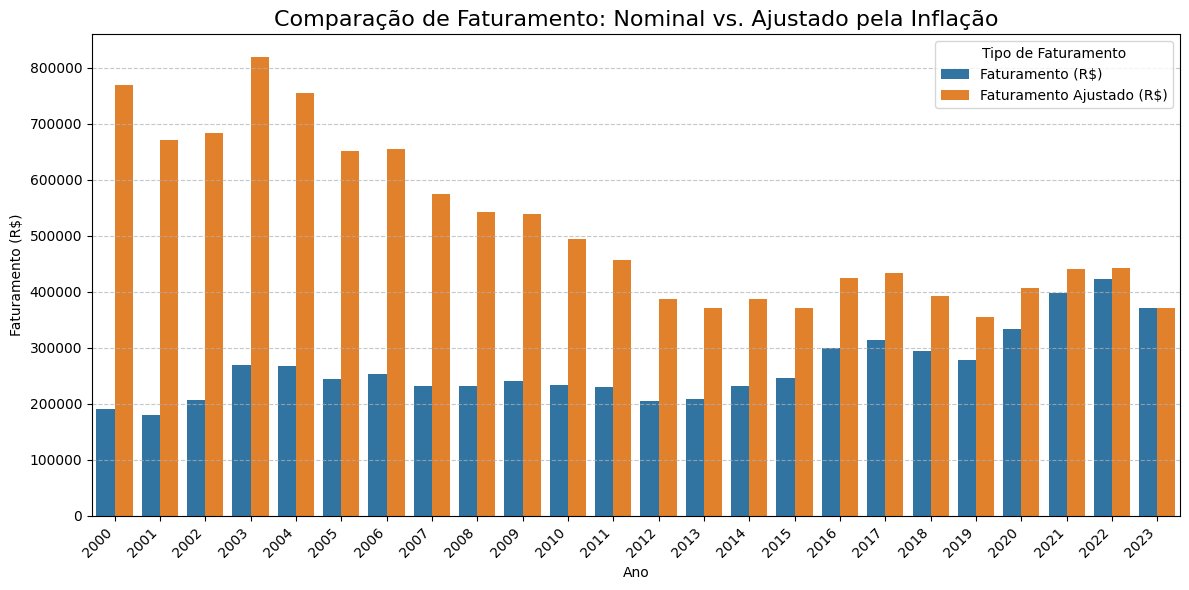

In [126]:
df_long = pd.melt(melted_faturamento_br, id_vars=['Ano'],
                  value_vars=['Faturamento (R$)', 'Faturamento Ajustado (R$)'],
                  var_name='Tipo de Faturamento',
                  value_name='Valor (R$)')

# Crie o gráfico de barras
plt.figure(figsize=(12, 6))

sns.barplot(data=df_long, x='Ano', y='Valor (R$)', hue='Tipo de Faturamento')

# Adicione títulos e rótulos
plt.title('Comparação de Faturamento: Nominal vs. Ajustado pela Inflação', fontsize=16)
plt.xlabel('Ano')
plt.ylabel('Faturamento (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajuste os rótulos do eixo X para que sejam visíveis
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Com o Faturamento ajustado pelo IPCA **2003** acaba sendo o ano com maior faturamento, e se torna possível visualizar que apesar do valor bruto faturado com a venda de mel ter aumentado, a verdade é que se esta ganhando menos.

#### Em qual ano o Brasil mais produziu mel?

##### Extração

Vamos repetir as operações anteriores

In [133]:
producao_br = pd.read_csv('data/producao mel/Producao Kg - Mel de Abelha - Brasil - 2000 2023.csv')
producao_br.info()
display(producao_br)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Sigla   1 non-null      object
 1   Código  1 non-null      int64 
 2   Brasil  1 non-null      object
 3   2000    1 non-null      int64 
 4   2001    1 non-null      int64 
 5   2002    1 non-null      int64 
 6   2003    1 non-null      int64 
 7   2004    1 non-null      int64 
 8   2005    1 non-null      int64 
 9   2006    1 non-null      int64 
 10  2007    1 non-null      int64 
 11  2008    1 non-null      int64 
 12  2009    1 non-null      int64 
 13  2010    1 non-null      int64 
 14  2011    1 non-null      int64 
 15  2012    1 non-null      int64 
 16  2013    1 non-null      int64 
 17  2014    1 non-null      int64 
 18  2015    1 non-null      int64 
 19  2016    1 non-null      int64 
 20  2017    1 non-null      int64 
 21  2018    1 non-null      int64 
 22  2019    1 non-null      int64 

,Sigla,Código,Brasil,2000,2001,2002,2003,2004,2005,2006,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,BR,0,Brasil,21865144,22204675,24028652,30022404,32290462,33749666,36193868,...,38481416,37859193,39677393,41695747,42407352,46088931,52493135,55678534,62494156,64188949


In [134]:
melted_producao_br = pd.melt(producao_br.drop(columns=['Sigla', 'Código']), id_vars=['Brasil'], var_name='Ano', value_name='Produção (Kg)')
show_head_tail(melted_producao_br)

,Brasil,Ano,Produção (Kg)
0,Brasil,2000,21865144
1,Brasil,2001,22204675
2,Brasil,2002,24028652
3,Brasil,2003,30022404
4,Brasil,2004,32290462


,Brasil,Ano,Produção (Kg)
19,Brasil,2019,46088931
20,Brasil,2020,52493135
21,Brasil,2021,55678534
22,Brasil,2022,62494156
23,Brasil,2023,64188949


In [135]:
melted_producao_br['Ano'] = melted_faturamento_br['Ano'].astype(int)

##### Resultado

In [136]:
show_max(melted_producao_br,'Produção (Kg)')
show_min(melted_producao_br,'Produção (Kg)')

Máximo valor em Produção (Kg)


,Brasil,Ano,Produção (Kg)
23,Brasil,2023,64188949


Mínimo valor em Produção (Kg)


,Brasil,Ano,Produção (Kg)
0,Brasil,2000,21865144


**2023** Foi o ano que o Brasil mais Produziu Mel. E percebemos que não é o mesmo ano que teve o maior faturamento.

#### E em qual ano o mel teve seu maior preço?

Pare responder essa pergunta vamos unir as duas tabelas anteriores. Estaremos levando me conta o faturamento ajustado para os cálculos.

In [137]:
mel_br = melted_producao_br.merge(melted_faturamento_br, on=['Brasil', 'Ano'],how='inner')
show_head_tail(mel_br)

,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
0,Brasil,2000,21865144,191235.448330,4.023398,769416.339531
1,Brasil,2001,22204675,179290.160265,3.736667,669947.680919
2,Brasil,2002,24028652,205953.340512,3.320588,683886.292978
3,Brasil,2003,30022404,269407.150088,3.038036,818468.514089
4,Brasil,2004,32290462,267114.750166,2.823466,754189.520224


,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
19,Brasil,2019,46088931,278263.994179,1.273111,354261.014774
20,Brasil,2020,52493135,334416.942334,1.218085,407348.184815
21,Brasil,2021,55678534,397418.252929,1.106736,439837.179171
22,Brasil,2022,62494156,422375.012785,1.046212,441893.764660
23,Brasil,2023,64188949,371282.235818,1.000000,371282.235818


In [138]:
show_max(mel_br,'Produção (Kg)')
show_max(mel_br,'Faturamento Ajustado (R$)')

Máximo valor em Produção (Kg)


,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
23,Brasil,2023,64188949,371282.235818,1.0,371282.235818


Máximo valor em Faturamento Ajustado (R$)


,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
3,Brasil,2003,30022404,269407.150088,3.038036,818468.514089


Aqui criamo o dado que faltava, o preço médio por kilograma.

In [139]:
mel_br['Preço do mel por Kg produzido'] = mel_br['Faturamento Ajustado (R$)']/mel_br['Produção (Kg)']
show_head_tail(mel_br)
show_max(mel_br,'Preço do mel por Kg produzido')

,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$),Preço do mel por Kg produzido
0,Brasil,2000,21865144,191235.448330,4.023398,769416.339531,0.035189
1,Brasil,2001,22204675,179290.160265,3.736667,669947.680919,0.030171
2,Brasil,2002,24028652,205953.340512,3.320588,683886.292978,0.028461
3,Brasil,2003,30022404,269407.150088,3.038036,818468.514089,0.027262
4,Brasil,2004,32290462,267114.750166,2.823466,754189.520224,0.023356


,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$),Preço do mel por Kg produzido
19,Brasil,2019,46088931,278263.994179,1.273111,354261.014774,0.007686
20,Brasil,2020,52493135,334416.942334,1.218085,407348.184815,0.007760
21,Brasil,2021,55678534,397418.252929,1.106736,439837.179171,0.007900
22,Brasil,2022,62494156,422375.012785,1.046212,441893.764660,0.007071
23,Brasil,2023,64188949,371282.235818,1.000000,371282.235818,0.005784


Máximo valor em Preço do mel por Kg produzido


,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$),Preço do mel por Kg produzido
0,Brasil,2000,21865144,191235.44833,4.023398,769416.339531,0.035189


**2003** foi o ano em que o mel teve seu maior preço por kg, ou seja, mesmo que com o passar do tempo tenha se produzido mais e faturado mais, isso não implica que o preço do mel valorizou. Gráfico abaixo deve demonstrar melhor essa comparação.

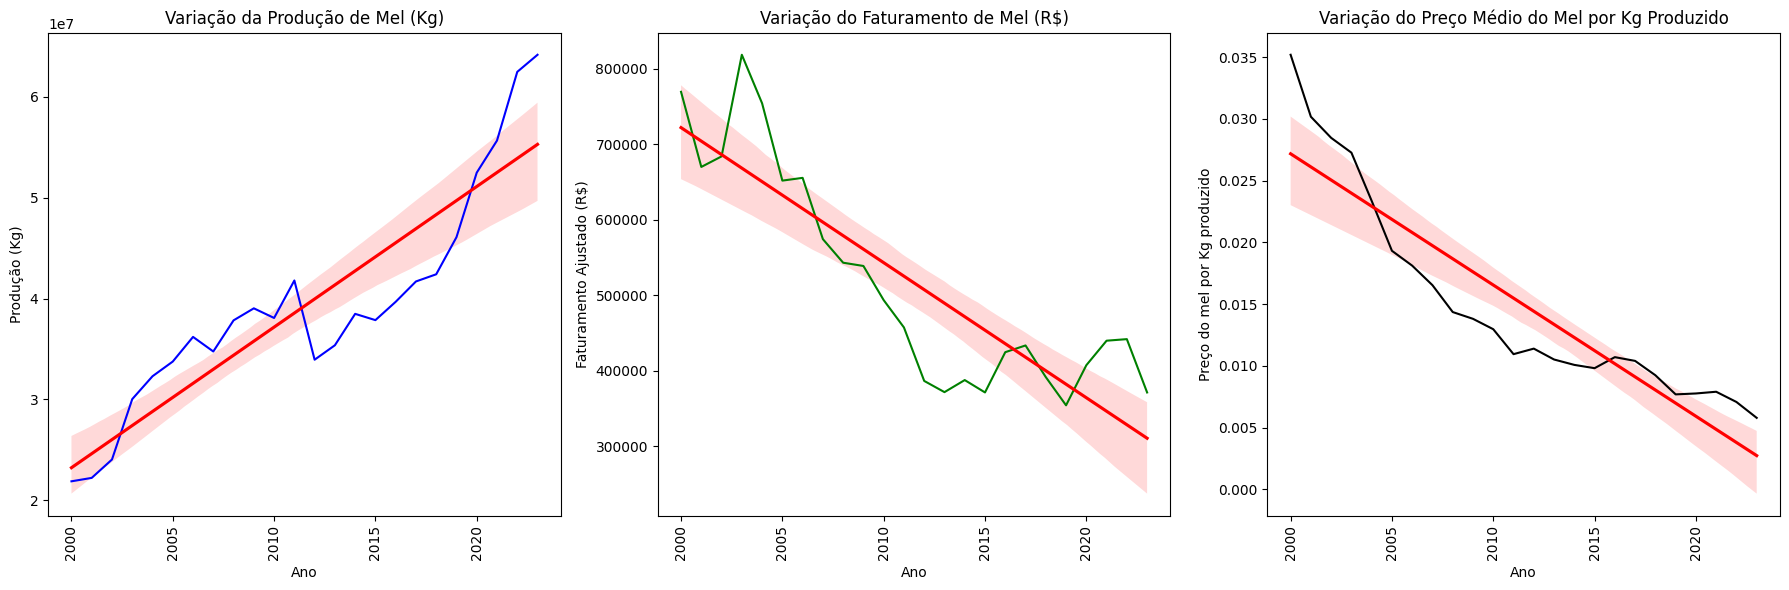

In [140]:
#Convertendo ano para numérico
mel_br['Ano'] = pd.to_numeric(mel_br['Ano'])

# Criar a figura e os 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Produção (Kg) com linha de tendência
sns.lineplot(data=mel_br, x='Ano', y='Produção (Kg)', ax=axes[0], color='blue')
sns.regplot(data=mel_br, x='Ano', y='Produção (Kg)', ax=axes[0], color='red', scatter=False, ci=95)
axes[0].set_title('Variação da Produção de Mel (Kg)')
axes[0].set_ylabel('Produção (Kg)')
axes[0].tick_params(axis='x', rotation=90)

# Gráfico 2: Faturamento Ajustado (R$) com linha de tendência
sns.lineplot(data=mel_br, x='Ano', y='Faturamento Ajustado (R$)', ax=axes[1], color='green')
sns.regplot(data=mel_br, x='Ano', y='Faturamento Ajustado (R$)', ax=axes[1], color='red', scatter=False, ci=95)
axes[1].set_title('Variação do Faturamento de Mel (R$)')
axes[1].set_ylabel('Faturamento Ajustado (R$)')
axes[1].tick_params(axis='x', rotation=90)

# Gráfico 3: Preço por Kg com linha de tendência
sns.lineplot(data=mel_br, x='Ano', y='Preço do mel por Kg produzido', ax=axes[2], color='black')
sns.regplot(data=mel_br, x='Ano', y='Preço do mel por Kg produzido', ax=axes[2], color='red', scatter=False, ci=95)
axes[2].set_title('Variação do Preço Médio do Mel por Kg Produzido')
axes[2].set_ylabel('Preço do mel por Kg produzido')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Com ajuda dos gráficos e suas linhas de tendencia conseguimos ver que apesar da produção do mel ter aumentado, ele é uma produto que tem passado por desvalorização com passar do tempo desdo o inicio do seculo. E apesar de ter tido uma valorização no período de 2016 e 2022, ele não alcançou mais o preço de 2003.

Pontos interessantes nos gráficos são:
1. O declínio da produção no período de 2012, que conforme a noticia do [Agrolink](https://www.agrolink.com.br/noticias/ibge--seca-faz-producao-nacional-de-mel-cair-19--em-2012_184745.html) foi causada pelo período de seca que ocorreu esse ano, e que a recuperação desse período de seca nos anos seguintes pode ter ocasionado a valorização nos anos seguinte, começando em 2013.
2. O outro declínio que aconteceu em 2019, porem esse não estando relacionado a produção de mel, permitindo assim concluir que o o valor do mel e as vendas não são unicamente influenciadas pela produção.


### Regiões

Nesta sessão estaremos utilizando o dataset separado por regiões, que possui a mesma fonte do nacional

In [146]:
producao_rg = pd.read_csv('data/producao mel/Producao Kg - Mel de Abelha - Regiões - 2000 2023.csv', delimiter=',', header=1)
producao_rg

,Sigla,Código,Região,2000,2001,2002,2003,2004,2005,2006,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,CO,5,Região Centro-oeste,631704,670833,683466,851928,916724,1097459,1189814,...,1682835,1587185,1699572,1971951,1529281,1794364,1856422,1731791,1508226,1801330
1,N,1,Região Norte,301696,317515,371143,509863,518834,653467,673729,...,1051946,948348,905534,802915,890099,1023003,999484,1129658,1252765,1282975
2,NE,2,Região Nordeste,3748108,3799504,5560006,7967658,10401191,10910916,12102924,...,10555158,12305251,10458385,12806050,14126096,15588516,19338339,20244963,24625523,25624482
3,S,4,Região Sul,12670098,12730601,12277442,15357099,15266363,15815522,16422483,...,16462708,14119128,17146509,16480865,16627518,17833466,20391853,22204521,22693682,21833880
4,SE,3,Região Sudeste,4513538,4686222,5136595,5335856,5187350,5272302,5804918,...,8728769,8899281,9467393,9633966,9234358,9849582,9907037,10367601,12413960,13646282


In [155]:
melted_producao_rg = pd.melt(producao_rg, id_vars=['Sigla','Código','Região'],var_name='Ano', value_name='Produção (Kg)')
show_head_tail(melted_producao_rg)

,Sigla,Código,Região,Ano,Produção (Kg)
0,CO,5,Região Centro-oeste,2000,631704
1,N,1,Região Norte,2000,301696
2,NE,2,Região Nordeste,2000,3748108
3,S,4,Região Sul,2000,12670098
4,SE,3,Região Sudeste,2000,4513538


,Sigla,Código,Região,Ano,Produção (Kg)
115,CO,5,Região Centro-oeste,2023,1801330
116,N,1,Região Norte,2023,1282975
117,NE,2,Região Nordeste,2023,25624482
118,S,4,Região Sul,2023,21833880
119,SE,3,Região Sudeste,2023,13646282


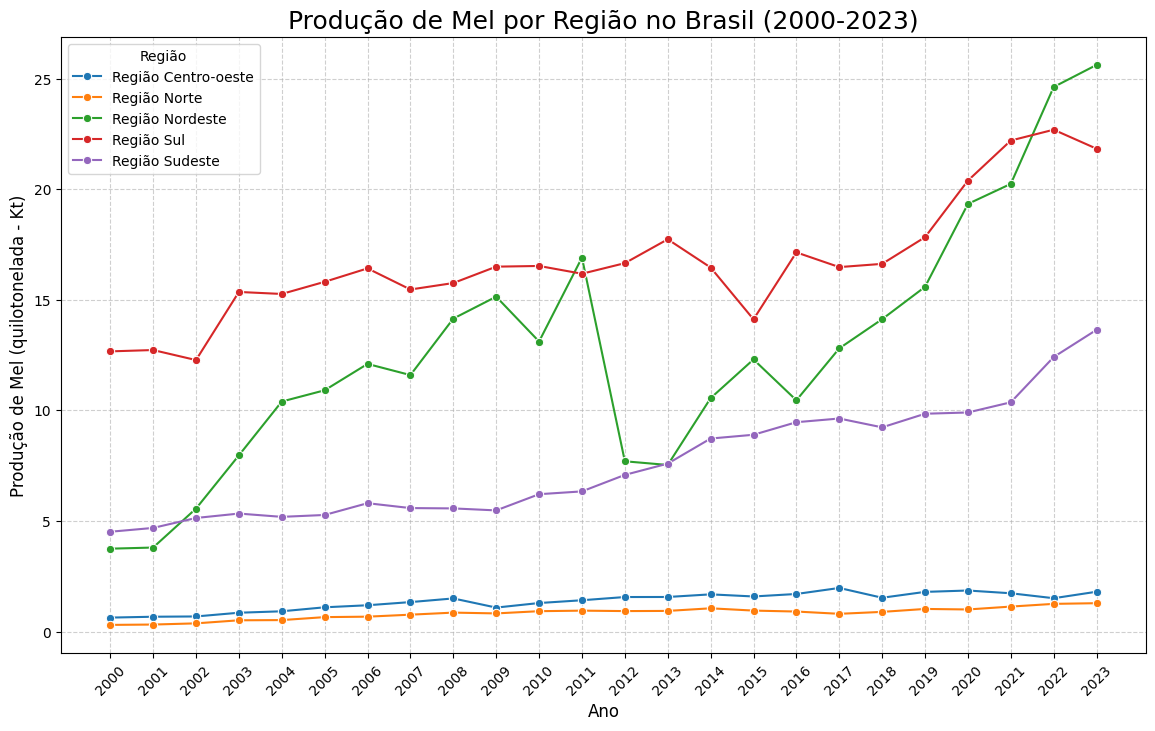

In [159]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Supondo que o seu DataFrame se chame 'melted_producao_rg'

plt.figure(figsize=(14, 8))
sns.lineplot(data=melted_producao_rg, x='Ano', y='Produção (Kg)', hue='Região', marker='o')

# Adicione título e rótulos
plt.title('Produção de Mel por Região no Brasil (2000-2023)', fontsize=18)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Produção de Mel (quilotonelada - Kt)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Formate os rótulos do eixo Y para mostrar em milhões
def millions_formatter(x, pos):
    """Função para formatar os valores do eixo Y em milhões."""
    return f'{x / 1e6:,.0f}'

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(millions_formatter))

# Adicione a legenda
plt.legend(title='Região', loc='upper left')

# Rotacione os rótulos do eixo X para melhor leitura
plt.xticks(melted_producao_rg['Ano'].unique(), rotation=45)

plt.show()

O gráfico acima nos permite visualizar quais são as principais regiões responsáveis pela produção de mel no Brasil desde o início do século XXI. Como esperado, a **Região Sul**, **Nordeste** e **Sudeste** se destacam, sendo as que mais contribuem para o volume total de mel produzido no país.

No entanto, a análise do gráfico revela mais do que apenas a liderança. É possível observar o comportamento distinto de cada uma dessas regiões ao longo do tempo:

* **Região Sul**: Apresenta um crescimento constante na produção, com uma curva ascendente que reflete o fortalecimento do setor apícola na região. É notável que, apesar de flutuações, a tendência geral é de alta.

* **Região Nordeste**: Tem um crescimento significativo, mas com uma alta volatilidade. É possível observar um crescimento inicial forte, seguido por uma queda brusca entre 2011 e 2012, e uma recuperação impressionante a partir de 2017, superando as outras regiões. Essa dinâmica sugere uma sensibilidade maior a fatores externos, como mudanças climáticas.

* **Região Sudeste**:  Apresenta um crescimento constante e estável, sem as grandes oscilações vistas em outras regiões. A produção tem uma tendência de alta clara, mostrando um desenvolvimento sólido e menos suscetível a flutuações.

Além disso, as regiões de menor produção, **Norte** e **Centro-Oeste**, se mantêm em patamares significativamente mais baixos. Ambas apresentam uma produção relativamente estável, sem as grandes oscilações ou tendências de crescimento acentuado vistas nas demais regiões.

Em resumo, o gráfico mostra que, embora três regiões dominem a produção, a dinâmica e a tendência de crescimento de cada uma são únicas, refletindo as particularidades de seus ecossistemas e do cenário econômico ao qual estão expostas.